In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os

from RegressionMultivariate.features_normalize import features_normalize_by_std
from RegressionMultivariate.features_normalize import features_normalizes_by_min_max
from RegressionMultivariate.compute_cost_multi import compute_cost_multi
from RegressionMultivariate.gradient_descent_multi import gradient_descent_multi
from RegressionMultivariate.gradient_descent_multi import gradient_descent_multi_with_history
from RegressionMultivariate.normal_eqn import normal_eqn

In [26]:
def costs_from_history(X_b: np.ndarray, y: np.ndarray, thetas: np.ndarray) -> np.ndarray:
    """Calcula o custo J(θ) para cada θ em *thetas*."""
    return np.array([compute_cost_multi(X_b, y, th) for th in thetas])

In [27]:
#Load data
os.makedirs("Figures", exist_ok=True)
data = np.loadtxt('Data/ex1data2.txt', delimiter=',')

In [28]:
X = data[:, :2] 
y = data[:, 2]
m = y.shape[0]

In [29]:
# 3) Normaliza features
X_norm2, mu2, sigma2 = features_normalize_by_std(X)
X_norm3, mu3, sigma3 = features_normalizes_by_min_max(X)
X_b1 = np.column_stack((np.ones((X.shape[0], 1)), X))
X_b2 = np.column_stack((np.ones((X_norm2.shape[0], 1)), X_norm2))
X_b3 = np.column_stack((np.ones((X_norm3.shape[0], 1)), X_norm3)) 

In [30]:
# 4) Gradient Descent Multivariado
alpha = 0.01
num_iters = 400
theta_gd1 = np.zeros(X_b1.shape[1])
theta_gd2 = np.zeros(X_b2.shape[1])
theta_gd3 = np.zeros(X_b3.shape[1])

In [31]:
theta_gd1, J_history1 = gradient_descent_multi(X_b1, y, theta_gd1, alpha, num_iters)
theta_gd2, J_history2 = gradient_descent_multi(X_b2, y, theta_gd2, alpha, num_iters)
theta_gd3, J_history3 = gradient_descent_multi(X_b3, y, theta_gd3, alpha, num_iters)

In [39]:
# 5) Predição com GD
example = np.array([1650, 3])
example_norm = (example - mu2) / sigma2
x_pred = np.concatenate(([1], example_norm))
price_gd = x_pred @ theta_gd2
print(f'\nPreço previsto (GD) para [1650,3]: ${price_gd:.2f}')


Preço previsto (GD) para [1650,3]: $289221.55


In [40]:
#6) Equação normal
X_ne = np.column_stack((np.ones(X.shape[0]), X))
theta_ne = normal_eqn(X_ne, y)
example = np.array([1, 1650, 3])

In [44]:
cost_ne_errado = compute_cost_multi(X_b2, y, theta_ne)
print(f'\n[CUSTO ERRADO] Custo usando θ_ne em X_NORMALIZADO (X_b): {cost_ne_errado:.2f}')


[CUSTO ERRADO] Custo usando θ_ne em X_NORMALIZADO (X_b): 39606006377.94


In [47]:
cost_ne_correto = compute_cost_multi(X_ne, y, theta_ne)
print(f'[CUSTO CORRETO] Custo usando θ_ne em X_ORIGINAL (X_ne): {cost_ne_correto:.2f}')

[CUSTO CORRETO] Custo usando θ_ne em X_ORIGINAL (X_ne): 2043280050.60


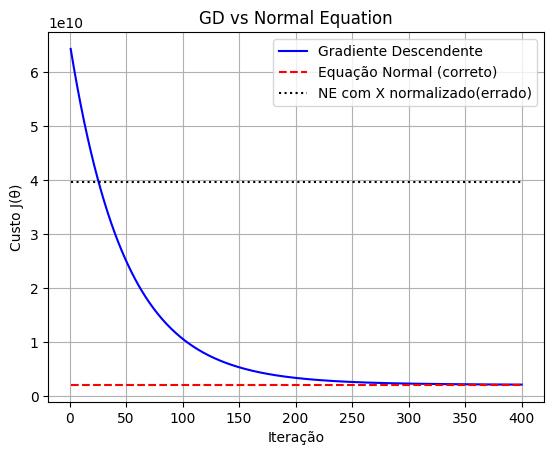

In [50]:
# Também podemos comparar visualmente no gráfico:
plt.figure()
plt.plot(np.arange(1, num_iters + 1), J_history2,
         'b-', label='Gradiente Descendente')
plt.hlines(cost_ne_correto, 1, num_iters,
           colors='r', linestyles='--',
           label='Equação Normal (correto)')
# Se quiséssemos, poderíamos plotar também a linha do custo errado:
plt.hlines(cost_ne_errado, 1, num_iters, colors='k', linestyles=':', label='NE com X normalizado(errado)')
plt.xlabel('Iteração')
plt.ylabel('Custo J(θ)')
plt.title('GD vs Normal Equation')
plt.legend()
plt.grid(True)
#plt.savefig('Figures/convergencia_custo_vs_ne.png', dpi=300, bbox_inches='tight')
#plt.savefig('Figures/convergencia_custo_vs_ne.svg', format='svg', bbox_inches='tight')
plt.show()